In [123]:
# Import required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("All libraries imported successfully!")

All libraries imported successfully!


In [124]:
# Load the Dataset
df = pd.read_csv('data/telco_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [125]:
# Data overview
print("=== DATASET OVERVIEW ===")
print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)
print("\nBasic Stats:")
df.describe()

=== DATASET OVERVIEW ===
Shape: (7043, 21)

Column Names: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Missing Values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data Types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [126]:
# Clean the data

# TotalCharges is text, convert to number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Convert Churn Yes/No to 1/0
df['Churn'] = np.where(df['Churn'] == 'Yes',1 ,0)

# Verifying everything is fixed
print("TotalCharges type now:", df['TotalCharges'].dtype)
print("Missing values remaining:", df.isnull().sum().sum())
print("\nChurn distribution:")
print(df['Churn'].value_counts())

TotalCharges type now: float64
Missing values remaining: 0

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [127]:
# Analyze the data

# Overall churn rate
churn_rate = df['Churn'].mean() * 100
print("=== KEY ANALYSIS ===")
print(f"1. Overall Churn Rate: {churn_rate:.2f}%")

# Churn by Contract Type
print("\n2. Churn Rate by Contract Type:")
contract_churn = df.groupby('Contract')['Churn'].mean() * 100
print(contract_churn.round(2))

# Average Monthly Charges (churned vs stayed)
print("\n3. Average Monthly Charges:")
charges = df.groupby('Churn')['MonthlyCharges'].mean()
print(f"Customers who stayed : ${charges[0]:.2f}")
print(f"Customers who churned: ${charges[1]:.2f}")

# Average Tenure (churned vs stayed)
print("\n4. Average Tenure (months):")
tenure = df.groupby('Churn')['tenure'].mean()
print(f"Customers who stayed : {tenure[0]:.1f} months")
print(f"Customers who churned: {tenure[1]:.1f} months")

# Churn by Internet Service
print("\n5. Churn Rate by Internet Service:")
internet_churn = df.groupby('InternetService')['Churn'].mean() * 100
print(internet_churn.round(2))


=== KEY ANALYSIS ===
1. Overall Churn Rate: 26.54%

2. Churn Rate by Contract Type:
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64

3. Average Monthly Charges:
Customers who stayed : $61.27
Customers who churned: $74.44

4. Average Tenure (months):
Customers who stayed : 37.6 months
Customers who churned: 18.0 months

5. Churn Rate by Internet Service:
InternetService
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Churn, dtype: float64


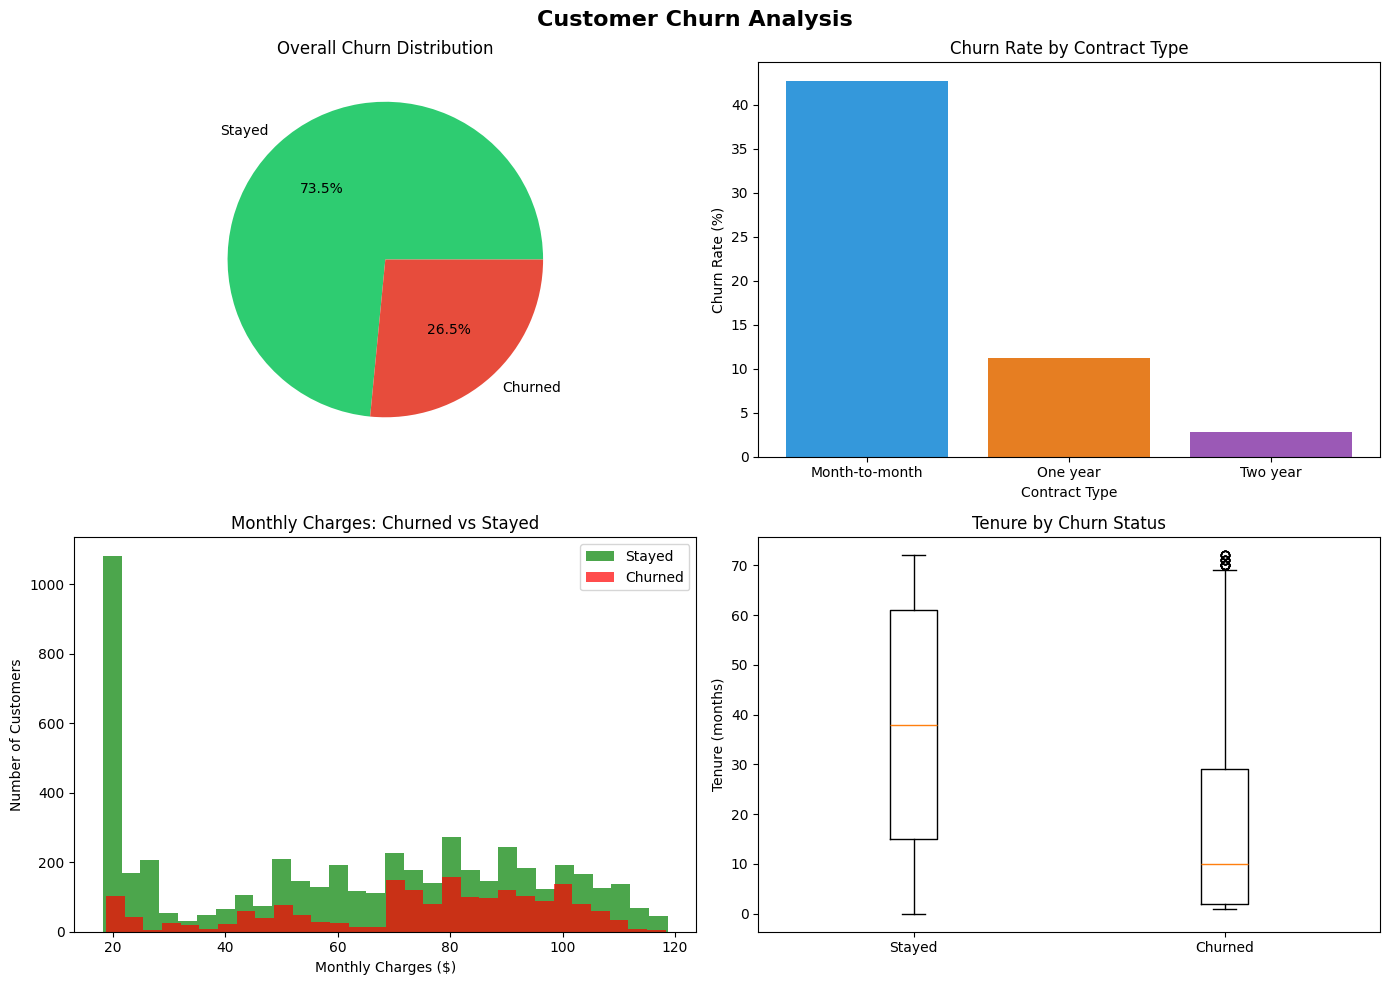

Charts saved to visuals folder!


In [128]:
# Visualize the Data

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Churn Analysis', fontsize=16, fontweight='bold')

# Chart 1 - Pie Chart (overall churn distribution)
churn_counts = df['Churn'].value_counts()
axes[0, 0].pie(churn_counts,
               labels=['Stayed', 'Churned'],
               autopct='%1.1f%%',
               colors=['#2ecc71', '#e74c3c'])
axes[0, 0].set_title('Overall Churn Distribution')

# Chart 2 - Bar Chart (churn rate by contract type)
contract_churn = df.groupby('Contract')['Churn'].mean() * 100
axes[0, 1].bar(contract_churn.index,
               contract_churn.values,
               color=['#3498db', '#e67e22', '#9b59b6'])
axes[0, 1].set_title('Churn Rate by Contract Type')
axes[0, 1].set_ylabel('Churn Rate (%)')
axes[0, 1].set_xlabel('Contract Type')

# Chart 3 - Histogram (monthly charges)
axes[1, 0].hist(df[df['Churn']==0]['MonthlyCharges'],
                alpha=0.7, label='Stayed', color='green', bins=30)
axes[1, 0].hist(df[df['Churn']==1]['MonthlyCharges'],
                alpha=0.7, label='Churned', color='red', bins=30)
axes[1, 0].set_title('Monthly Charges: Churned vs Stayed')
axes[1, 0].set_xlabel('Monthly Charges ($)')
axes[1, 0].set_ylabel('Number of Customers')
axes[1, 0].legend()

# Chart 4 - Box Plot (tenure)
stayed_tenure = df[df['Churn']==0]['tenure']
churned_tenure = df[df['Churn']==1]['tenure']
axes[1, 1].boxplot([stayed_tenure, churned_tenure],
                   labels=['Stayed', 'Churned'])
axes[1, 1].set_title('Tenure by Churn Status')
axes[1, 1].set_ylabel('Tenure (months)')

plt.tight_layout()
plt.savefig('visuals/churn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved to visuals folder!")

In [129]:
# Summary

print("CUSTOMER CHURN ANALYSIS - KEY INSIGHTS")


print(f"""
OVERVIEW
-----------
Total Customers  : {len(df)}
Churned          : {df['Churn'].sum()} customers
Churn Rate       : {df['Churn'].mean() * 100:.2f}%

CONTRACT TYPE IMPACT
------------------------
Month-to-month   : {df[df['Contract']=='Month-to-month']['Churn'].mean()*100:.2f}% churn
One year         : {df[df['Contract']=='One year']['Churn'].mean()*100:.2f}% churn
Two year         : {df[df['Contract']=='Two year']['Churn'].mean()*100:.2f}% churn

MONTHLY CHARGES IMPACT
--------------------------
Avg charges (Stayed)  : ${df[df['Churn']==0]['MonthlyCharges'].mean():.2f}
Avg charges (Churned) : ${df[df['Churn']==1]['MonthlyCharges'].mean():.2f}

TENURE IMPACT
-----------------
Avg tenure (Stayed)   : {df[df['Churn']==0]['tenure'].mean():.1f} months
Avg tenure (Churned)  : {df[df['Churn']==1]['tenure'].mean():.1f} months

INTERNET SERVICE IMPACT
---------------------------
Fiber optic : {df[df['InternetService']=='Fiber optic']['Churn'].mean()*100:.2f}% churn
DSL         : {df[df['InternetService']=='DSL']['Churn'].mean()*100:.2f}% churn
No internet : {df[df['InternetService']=='No']['Churn'].mean()*100:.2f}% churn

BUSINESS RECOMMENDATIONS
-----------------------------
1. Push month-to-month customers toward longer contracts
2. Investigate why Fiber optic customers churn more
3. Focus retention efforts on first 10 months of customer journey
4. High monthly charge customers need special retention offers
""")

CUSTOMER CHURN ANALYSIS - KEY INSIGHTS

OVERVIEW
-----------
Total Customers  : 7043
Churned          : 1869 customers
Churn Rate       : 26.54%

CONTRACT TYPE IMPACT
------------------------
Month-to-month   : 42.71% churn
One year         : 11.27% churn
Two year         : 2.83% churn

MONTHLY CHARGES IMPACT
--------------------------
Avg charges (Stayed)  : $61.27
Avg charges (Churned) : $74.44

TENURE IMPACT
-----------------
Avg tenure (Stayed)   : 37.6 months
Avg tenure (Churned)  : 18.0 months

INTERNET SERVICE IMPACT
---------------------------
Fiber optic : 41.89% churn
DSL         : 18.96% churn
No internet : 7.40% churn

BUSINESS RECOMMENDATIONS
-----------------------------
1. Push month-to-month customers toward longer contracts
2. Investigate why Fiber optic customers churn more
3. Focus retention efforts on first 10 months of customer journey
4. High monthly charge customers need special retention offers

